In [25]:
%%bash
echo "Current Conda environment: ${CONDA_DEFAULT_ENV}"

Current Conda environment: scRNA2023


In [26]:
%matplotlib inline
import sys
import os
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
import datetime
import scipy
import matplotlib.pyplot as plt

#Read config file
import configparser as config
config = config.ConfigParser()
config.read('./config.ini')
data_path=config['PATHS']["wd"]+"git/"
os.chdir(data_path)

sc.settings.verbosity = 0         # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_versions()
sc.set_figure_params(scanpy=True, dpi=100, dpi_save=150,
                         frameon=True, vector_friendly=True, 
                         fontsize=14, color_map=None, format='pdf',
                         transparent=True )
sc._settings.n_jobs = 5
sc._settings.max_memory = 80 #GB
plt.rcParams['figure.figsize']=(5,5) #rescale figures
sc._settings.savefigs = True

-----
anndata     0.7.8
scanpy      1.9.3
-----
Cython                      3.0.2
PIL                         9.4.0
absl                        NA
aiohttp                     3.8.3
aiosignal                   1.2.0
annotated_types             0.5.0
anyio                       NA
asciitree                   NA
asttokens                   NA
async_timeout               4.0.2
attr                        22.1.0
backcall                    0.2.0
backoff                     2.2.1
beta_ufunc                  NA
binom_ufunc                 NA
bottleneck                  1.3.5
brotli                      NA
bs4                         4.12.2
certifi                     2023.07.22
cffi                        1.15.1
charset_normalizer          2.0.4
chex                        0.1.7
click                       8.1.7
cloudpickle                 2.2.1
colorama                    0.4.6
comm                        0.1.2
contextlib2                 NA
croniter                    NA
cycler             

# Load loom file

is created in velocity.ipynb

In [27]:
loom_path=data_path+"results/velocity/"
ldata = sc.read_loom(loom_path+"N4703m-N4704m_sorted_genome_bam.loom",  validate=False)
ldata.var_names_make_unique()
ldata

AnnData object with n_obs × n_vars = 15363 × 32285
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'sample'
    layers: 'matrix', 'ambiguous', 'spliced', 'unspliced'

# Velocity analysis 

In [30]:
adata = sc.read(data_path+"results/CelltypeIdentifcation_20230925_spleen.h5ad")

del adata.obs['doublet_scores']
del adata.obs['predicted_doublets']
del adata.layers
del adata.uns
del adata.varm
del adata.obsp

adata_mono_t = sc.read(data_path+"results/CelltypeIdentifcation_20230925_spleen_macro.h5ad")
adata.obs["leiden_mono"] = adata_mono_t.obs.leiden_mono
adata

AnnData object with n_obs × n_vars = 9230 × 16799
    obs: 'sample', 'batch', 'group', 'n_counts', 'percent_mito', 'n_genes', 'size_factors', 'leiden', 'putative_celltypes', 'celltypes', 'leiden_leftover', 'final_celltypes_sub', 'final_celltypes', 'leiden_mono'
    var: 'gene_ids', 'feature_types', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    obsm: 'X_pca', 'X_umap'

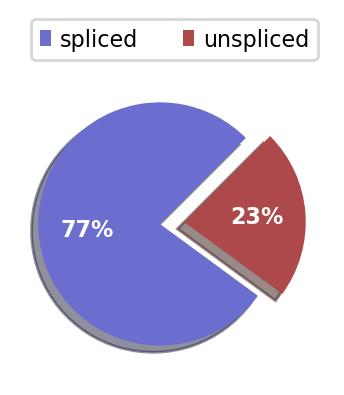

In [31]:
scv.utils.clean_obs_names(adata)
scv.utils.clean_obs_names(ldata)
adata = scv.utils.merge(adata, ldata)
scv.pl.proportions(adata)

In [32]:
scv.pp.moments(adata, n_pcs=20, n_neighbors=20)
scv.tl.velocity(adata)

Normalized count data: spliced, unspliced.
computing neighbors
    finished (0:00:37) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:06) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities
    finished (0:00:17) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


In [33]:
scv.tl.velocity_graph(adata)

computing velocity graph (using 1/32 cores)


  0%|          | 0/9230 [00:00<?, ?cells/s]

    finished (0:00:46) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


In [34]:
scv.tl.recover_dynamics(adata)
scv.tl.velocity(adata, mode='dynamical')
scv.tl.velocity_graph(adata)
adata.write('./results/scvelo_dynamic_data_spleen.h5ad', compression='gzip')

recovering dynamics (using 1/32 cores)


  0%|          | 0/1563 [00:00<?, ?gene/s]

    finished (0:26:33) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
computing velocities
    finished (0:00:33) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/32 cores)


  0%|          | 0/9230 [00:00<?, ?cells/s]

    finished (0:00:23) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


In [36]:
adata = scv.read('./results/scvelo_dynamic_data_spleen.h5ad')

/mnt/dzl_bioinf/exec/miniconda/miniconda3/envs/scRNA2023/lib/python3.9/site-packages/h5py/_hl/dataset.py:767: DeprecationWarning: Passing None into shape arguments as an alias for () is deprecated.
  arr = numpy.ndarray(selection.mshape, dtype=new_dtype)


computing velocity embedding
    finished (0:00:06) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


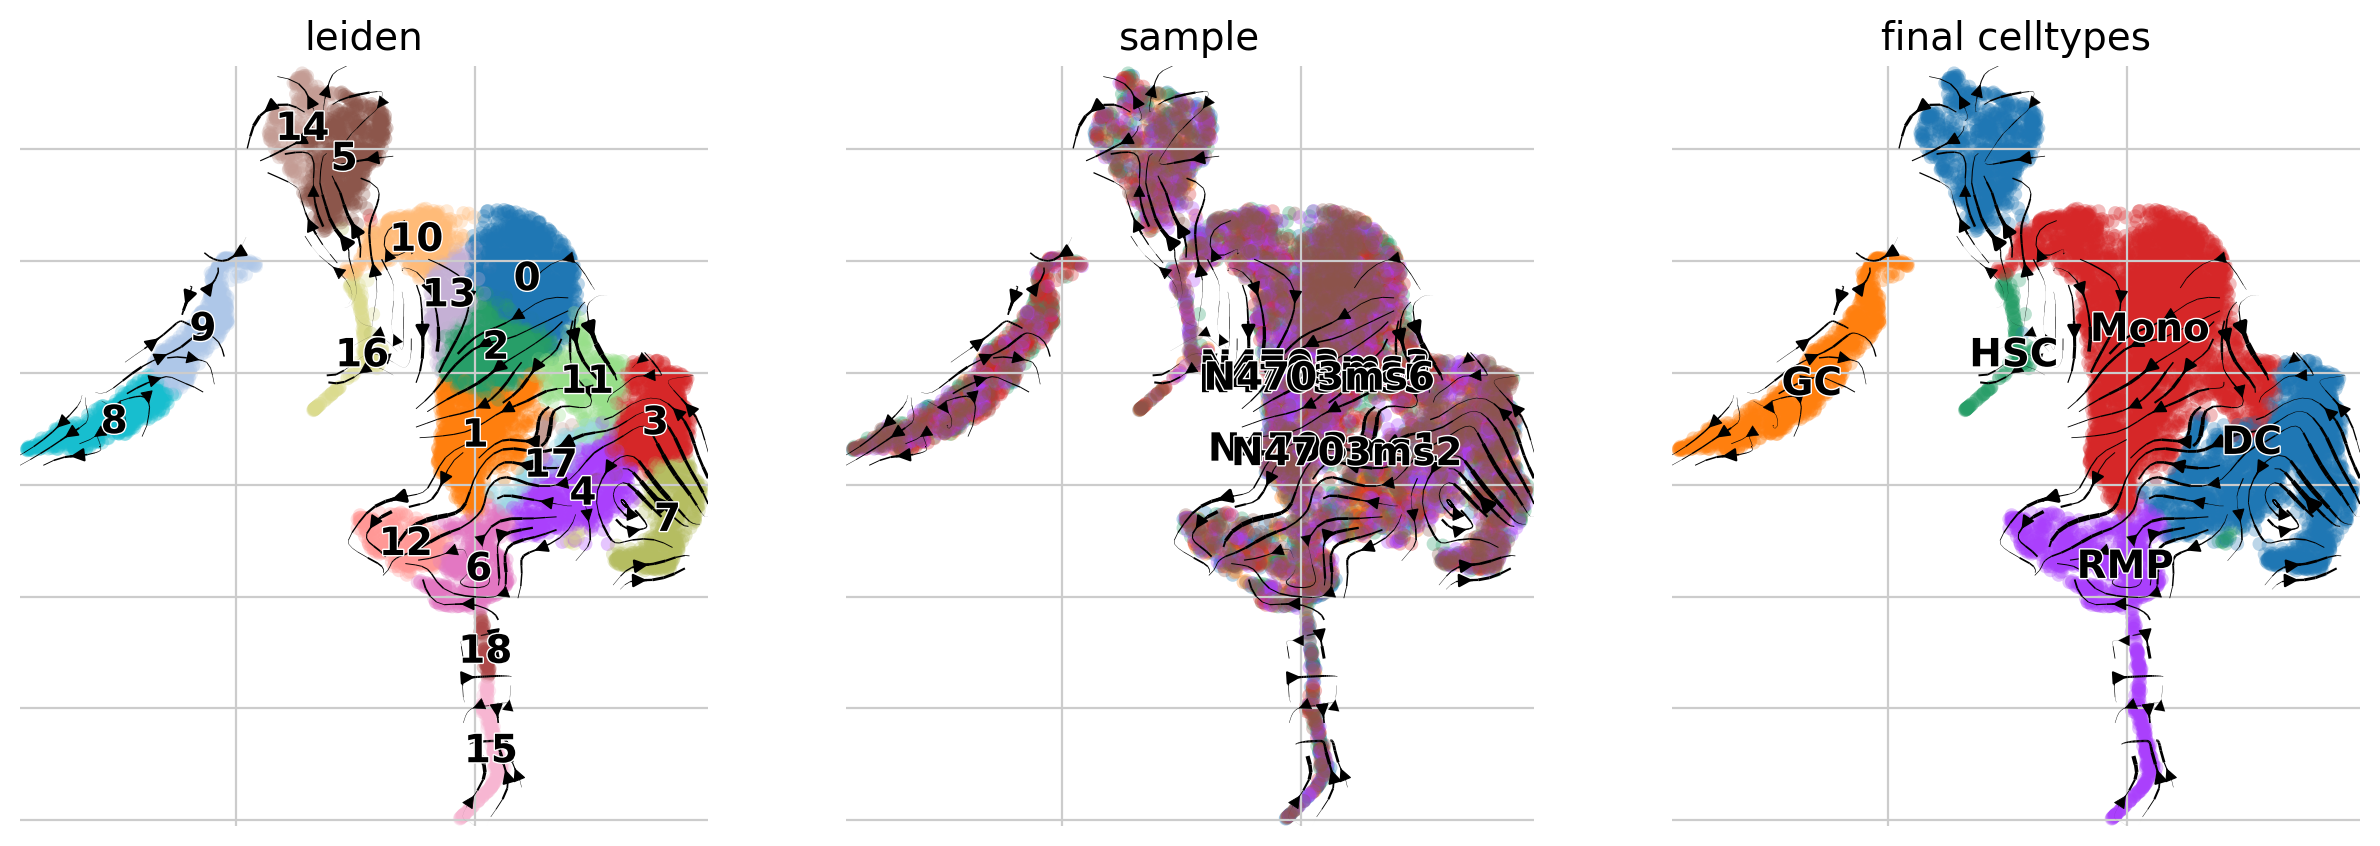

In [37]:
scv.pl.velocity_embedding_stream(adata, basis='umap', color=["leiden","sample","final_celltypes"])

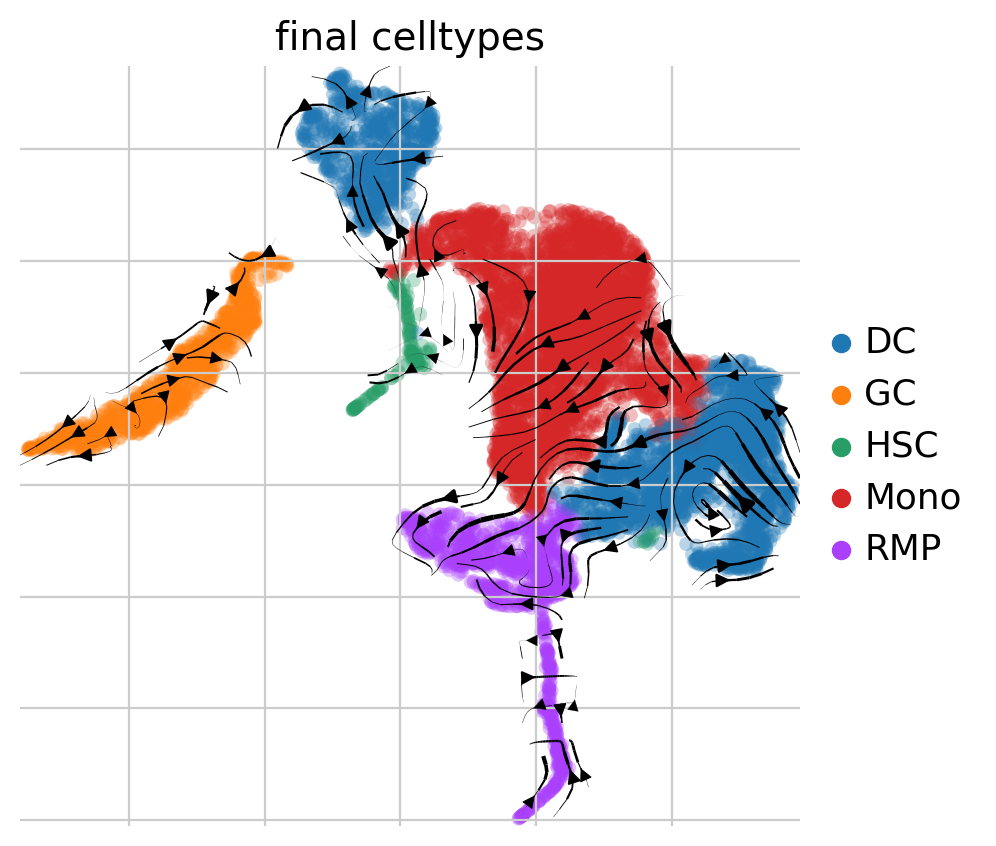

(None,)

In [38]:
scv.pl.velocity_embedding_stream(adata, basis='umap', color="final_celltypes", 
                                 legend_loc= "right margin")

NotchKO
saving figure to file ./figures/scvelo_velocity_dynamic2_mono_NotchKO.pdf


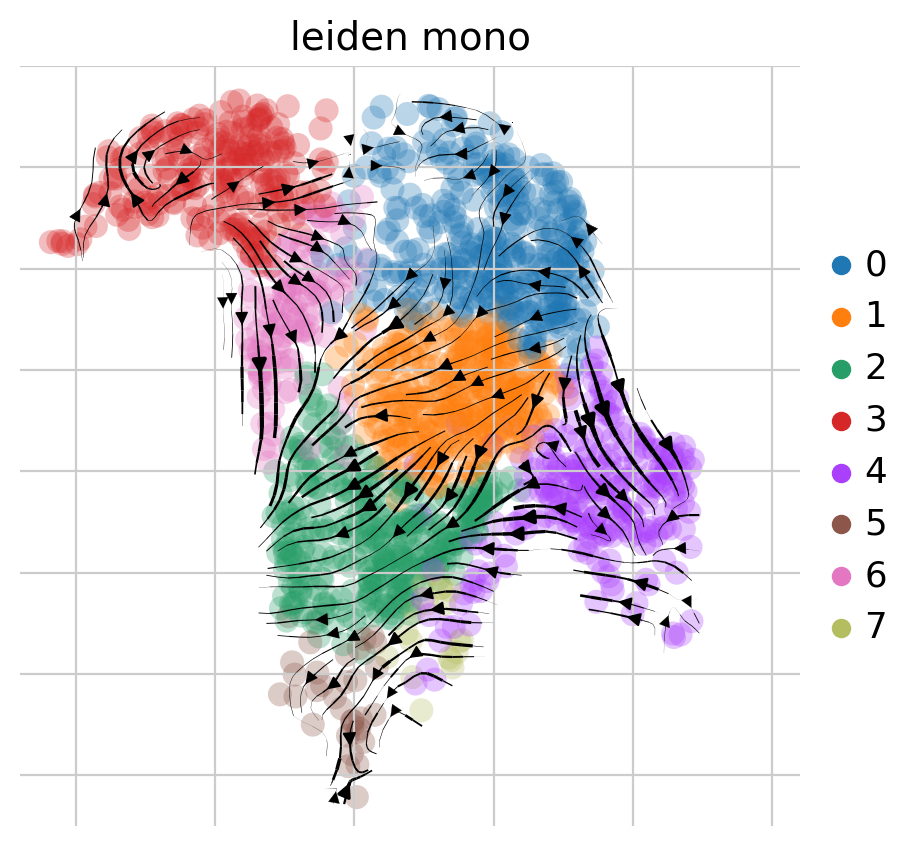

RbpjKO
figure cannot be saved as pdf, using png instead (can only output finite numbers in pdf).
saving figure to file ./figures/scvelo_velocity_dynamic2_mono_RbpjKO.png


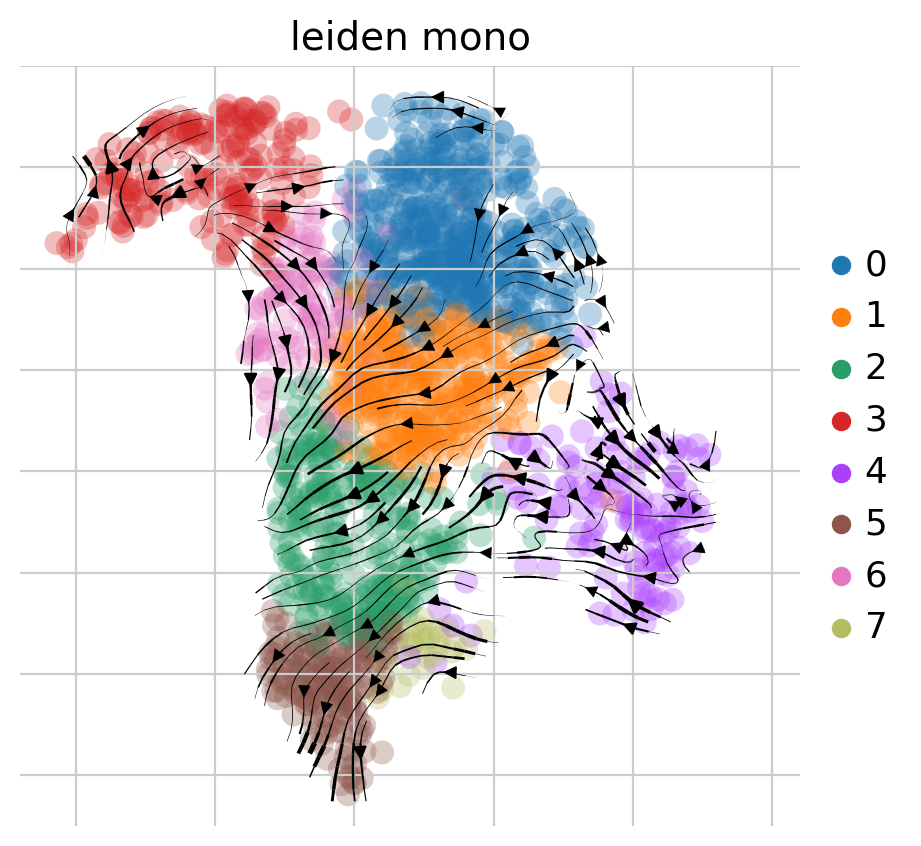

WT
figure cannot be saved as pdf, using png instead (can only output finite numbers in pdf).
saving figure to file ./figures/scvelo_velocity_dynamic2_mono_WT.png


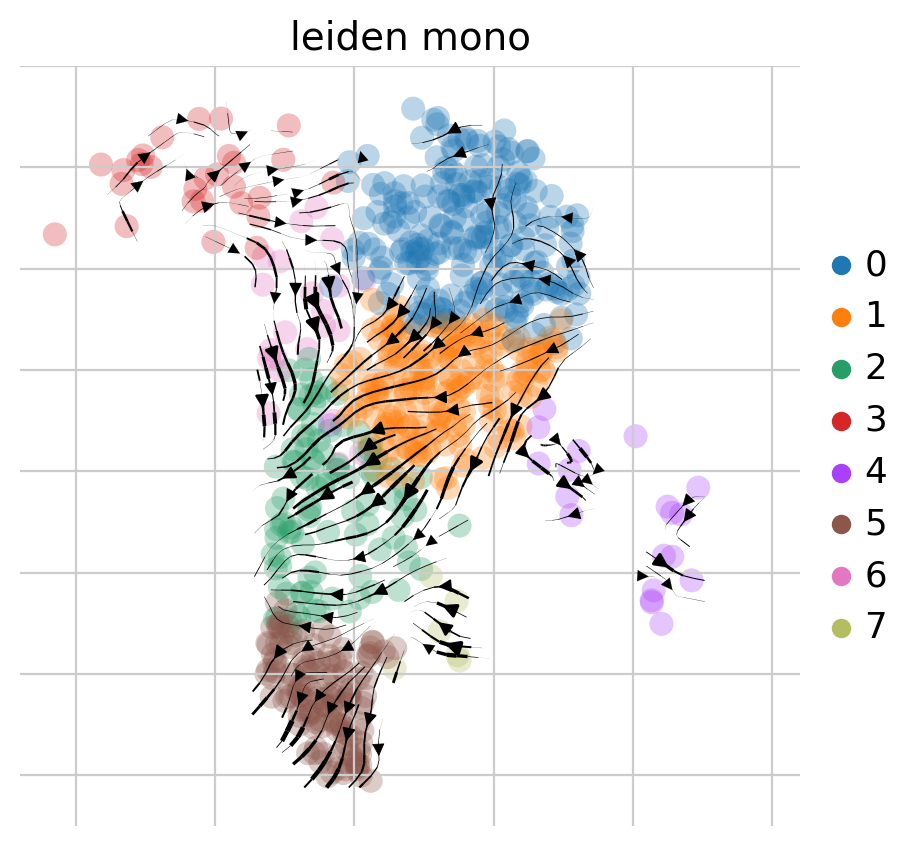

In [57]:
for g in np.unique(adata.obs.group):
    print(g)
    scv.pl.velocity_embedding_stream(adata[(adata.obs["group"] ==g) & (adata.obs["final_celltypes"] =="Mono"),], 
                                 basis='umap', color="leiden_mono", size=300,
                                 legend_loc= "right margin",
                                 xlim = [4,18],
                                 ylim=[3,18]) 

# Save

In [ ]:
%%bash
jupyter nbconvert --to html_toc Velocity_spleen.ipynb --ExtractOutputPreprocessor.enabled=False
mv Velocity_spleen.html ./results/spleen/Velocity_spleen_$(date +%Y%m%d).html 